# Ellipsoid Spectral Benchmark — One-Run Orchestrator

Dieses Notebook ist absichtlich **dünn**: keine Solver-Definitionen mehr im Notebook, sondern nur Konfiguration, Package-Imports, Benchmark-Aufrufe, Plots und Exporte.

Es bündelt drei Benchmark-Spuren:

1. **Unitball-QS**  
   \(a=b=c=1\), Vergleich gegen `unit_ball_N20000.txt`.

2. **Reverse Geometry / Weyl-QS**  
   \(a=1, b=1.5, c=2.3\), Volumen-/Oberflächenrekonstruktion via 2-Term-Weyl.

3. **Block-Hankel / Multi-Probe FDM**  
   Multi-Probe-Momente, Block-Hankel-Pencil, Stable-Pole-Filter.

Der normale Workflow:

```text
pip install -e hearing-ellipsoid-bench
↓
Konfiguration setzen
↓
Run-All-Zelle starten
↓
Ergebnisse in OUT_DIR prüfen
```


In [2]:
# ============================================================
# 1. Global configuration
# ============================================================

from pathlib import Path

PROJECT_ROOT = Path.home() / "hearing-ellipsoid-bench"
DATA_ROOT = Path.home() / "data"
REFERENCE_DIR = DATA_ROOT / "reference"
GENERATED_DIR = DATA_ROOT / "generated"
OUTPUTS_DIR = DATA_ROOT / "outputs"

OUT_DIR = OUTPUTS_DIR / "orchestrated_benchmark_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    # --------------------------------------------------------
    # General
    # --------------------------------------------------------
    "data_dir": DATA_ROOT,
    "out_dir": OUT_DIR,

    # --------------------------------------------------------
    # Track A: Unitball QS
    # --------------------------------------------------------
    "run_unit_ball": True,

    # If True, compute with SLEPc/ARPACK from K,M.
    # If False, load an existing numerical eigenvalue file and only validate.
    "unit_ball_compute": False,

    "unit_ball_truth_path": REFERENCE_DIR / "unit_ball_N20000.txt",

    # alternatively:
    #   "unit_ball_existing_eigs_path": GENERATED_DIR / "unit_ball_fem_N1000.txt",
    #   "n_target": 1000,
    "unit_ball_existing_eigs_path": GENERATED_DIR / "unit_ball_P2_h008_N5000_slepc_eigs.txt",

    "unit_ball": {
        "n_target": 5000,
        "mesh_size": 0.08,
        "order": 2,
        "solver": "slepc",          # "slepc" or "arpack"
        "force_remesh": False,
    },

    # --------------------------------------------------------
    # Track B: Reverse Geometry / Weyl QS
    # --------------------------------------------------------
    "run_reverse_geometry": True,
    "reverse_geometry": {
        "a": 1.0,
        "b": 1.5,
        "c": 2.3,
        "eig_files": {
            "SSG": GENERATED_DIR / "ssg_a1_b1.5_c2.3_eigenvalues.txt",
            "Arnoldi": REFERENCE_DIR / "ellipsoid_eigs_a1_b1.5_c2.3_arnoldi-1000.txt",
        },
        "k_values": [50, 100, 200, 300, 500, 700, 1000, 1500, 2000, 3000, 5000],
    },

    # --------------------------------------------------------
    # Track C: Block-Hankel / Multi-Probe FDM
    # --------------------------------------------------------
    "run_block_fdm": True,

    # This track assembles/loads K,M for unit ball and runs block-Hankel.
    # It is fast compared with SLEPc, but still several minutes.
    "block_fdm": {
        "mesh_size": 0.08,
        "order": 2,
        "force_remesh": False,
        "reference_index_top": 800,
        "n_moments": 4000,
        "n_windows": 8,
        "n_probes": 7,
        "hankel_blocks": 100,
        "transition_frac": 0.15,
        "window_overlap": 0.15,
        "seed": 42,
        "rank_tol": 1e-9,
        "max_rank": 350,
        "verbose": True,
    },

    # --------------------------------------------------------
    # Track D: Stable Pole Filter
    # --------------------------------------------------------
    "run_block_fdm_stability": True,
    "block_fdm_stability": {
        "seeds": [42, 137, 271, 314, 999],
        "n_moments": 2500,
        "n_windows": 8,
        "n_probes": 5,
        "hankel_blocks": 90,
        "min_count": 3,
        "rel_gap": 5e-4,
        "verbose": False,
    },

    # ------------------------------------------------------------
    # Track E: SSG
    # ------------------------------------------------------------
    "run_ssg_triaxial": True,
    "ssg_triaxial": {
        "a": 1.0,
        "b": 1.5,
        "c": 2.3,
        "run_sanity": True,
        "sanity": {
            "l_max": 6,
            "n_max": 5,
            "n_radial": 24,
            "n_theta": 18,
            "n_phi": 36,
            "max_rel_err_target": 1e-12,
        },
        "configs": [
            (10,  7, 28, 20, 40),
            (14,  9, 32, 24, 48),
            (18, 11, 36, 28, 56),
            (22, 13, 40, 32, 64),
            # (26, 15, 44, 36, 72),
            # (30, 18, 48, 40, 80),
        ],
        "reference_path": REFERENCE_DIR / "ellipsoid_eigs_a1_b1.5_c2.3_arnoldi-1000.txt",
        "save_eigs_to": GENERATED_DIR / "ssg_a1_b1.5_c2.3_eigenvalues.txt",
        "n_compare": 500,
        "block_size": None,
    },

    # ------------------------------------------------------------
    # Track F: DMC
    # ------------------------------------------------------------
    "run_dmc": True,
    "dmc": {
        "run_sanity": True,
        "sanity": {
            "a": 1.0,
            "b": 1.0,
            "c": 1.0,
            "n_walkers_per_run": 500_000,
            "n_runs_per_dt": 20,
            "dts": (0.004, 0.002, 0.001, 0.0005),
            "n_cores": 20,
        },
        "run_triaxial": True,
        "triaxial": {
            "a": 1.0,
            "b": 1.5,
            "c": 2.3,
            "n_walkers_per_run": 1_000_000,
            "n_runs_per_dt": 30,
            "dts": (0.004, 0.002, 0.001, 0.0005),
            "n_cores": 20,
        },
        "ssg_eigs_path": GENERATED_DIR / "ssg_a1_b1.5_c2.3_eigenvalues.txt",
        "arnoldi_eigs_path": REFERENCE_DIR / "ellipsoid_eigs_a1_b1.5_c2.3_arnoldi-1000.txt",
    },
}

print("DATA_ROOT:", DATA_ROOT)
print("REFERENCE_DIR:", REFERENCE_DIR)
print("GENERATED_DIR:", GENERATED_DIR)
print("OUT_DIR:", OUT_DIR)

DATA_ROOT: /home/esul01/data
REFERENCE_DIR: /home/esul01/data/reference
GENERATED_DIR: /home/esul01/data/generated
OUT_DIR: /home/esul01/data/outputs/orchestrated_benchmark_outputs


In [3]:
# ============================================================
# 2. Imports from the clean package
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hearing_ellipsoid_bench.io.eigenvalues import load_eigenvalues_txt, save_eigenvalues_txt
from hearing_ellipsoid_bench.core.types import AlgorithmResult, clean_eigenvalues
from hearing_ellipsoid_bench.fem.assembly import load_or_create_problem
from hearing_ellipsoid_bench.solvers.slepc import check_slepc, solve_slepc_krylov_schur
from hearing_ellipsoid_bench.solvers.arpack import solve_arpack_shift_invert
from hearing_ellipsoid_bench.solvers.fdm_block import (
    windowed_block_fdm,
    stable_pole_filter,
)
from hearing_ellipsoid_bench.validation.sphere import (
    compare_to_truth,
    error_bands,
    make_cluster_windows,
    inflate_windows,
)
from hearing_ellipsoid_bench.benchmarks.unit_ball import run_unit_ball_solver_benchmark
from hearing_ellipsoid_bench.benchmarks.reverse_geometry import run_reverse_geometry_benchmark
from hearing_ellipsoid_bench.viz.plots import plot_relative_error, plot_reverse_geometry

print("SLEPc available:", check_slepc())

from hearing_ellipsoid_bench.solvers.ssg import solve_ssg
from hearing_ellipsoid_bench.dmc.validation import solve_dmc_lambda1


SLEPc available: False


In [4]:
# ============================================================
# 3. Hardware/runtime metadata
# ============================================================
import os
import json
import platform
import subprocess

def get_hardware_specs():
    specs = {}
    specs["platform"] = platform.platform()
    specs["python"] = platform.python_version()

    try:
        import psutil
        specs["logical_cpus"] = psutil.cpu_count(logical=True)
        specs["physical_cpus"] = psutil.cpu_count(logical=False)
        specs["ram_gb"] = round(psutil.virtual_memory().total / 1024**3, 2)
    except Exception:
        specs["logical_cpus"] = os.cpu_count()
        specs["physical_cpus"] = None
        specs["ram_gb"] = None

    try:
        specs["cpu_model"] = subprocess.check_output(
            "lscpu | grep 'Model name' | cut -d ':' -f2 | xargs",
            shell=True,
            text=True,
        ).strip()
    except Exception:
        specs["cpu_model"] = "unknown"

    try:
        specs["kernel"] = subprocess.check_output("uname -a", shell=True, text=True).strip()
    except Exception:
        specs["kernel"] = "unknown"

    return specs

hardware_specs = get_hardware_specs()
display(pd.DataFrame([hardware_specs]))

(OUT_DIR / "hardware_specs.json").write_text(json.dumps(hardware_specs, indent=2), encoding="utf-8")


,platform,python,logical_cpus,physical_cpus,ram_gb,cpu_model,kernel
0,Linux-5.15.0-177-generic-x86_64-with-glibc2.35,3.12.1,128,128,377.49,AMD EPYC 9554 64-Core Processor,Linux n21 5.15.0-177-generic #187-Ubuntu SMP S...


325

# Helper: robust matching and export utilities

In [5]:
# ============================================================
# 4. Helper functions
# ============================================================

def save_json(obj, path: Path):
    def default(o):
        if isinstance(o, Path):
            return str(o)
        if isinstance(o, (np.integer, np.floating)):
            return o.item()
        if isinstance(o, np.ndarray):
            return o.tolist()
        return str(o)

    path.write_text(json.dumps(obj, indent=2, default=default), encoding="utf-8")
    print("saved:", path)


def match_to_reference_unique(eigs, ref, max_rel_err=None):
    eigs = clean_eigenvalues(eigs)
    ref = clean_eigenvalues(ref)

    used = np.zeros(len(ref), dtype=bool)
    rows = []

    for i, x in enumerate(eigs):
        diffs = np.abs(ref - x)
        diffs[used] = np.inf
        j = int(np.argmin(diffs))

        if not np.isfinite(diffs[j]):
            continue

        rel_err = abs(x - ref[j]) / max(abs(ref[j]), 1e-15)

        if max_rel_err is not None and rel_err > max_rel_err:
            continue

        used[j] = True

        rows.append({
            "i": i,
            "lambda_num": float(x),
            "lambda_ref": float(ref[j]),
            "ref_idx": int(j),
            "rel_err": float(rel_err),
        })

    return pd.DataFrame(rows)


def summarize_unique_match(eigs, ref, max_rel_err=0.05, label="method"):
    df = match_to_reference_unique(eigs, ref, max_rel_err=max_rel_err)

    summary = {
        "method": label,
        "n_raw": int(len(eigs)),
        "n_unique_matched": int(len(df)),
        "max_rel_err_threshold": max_rel_err,
        "ref_idx_min": int(df["ref_idx"].min()) if len(df) else None,
        "ref_idx_max": int(df["ref_idx"].max()) if len(df) else None,
        "median_rel_err": float(df["rel_err"].median()) if len(df) else np.nan,
        "max_rel_err": float(df["rel_err"].max()) if len(df) else np.nan,
        "q90_rel_err": float(np.percentile(df["rel_err"], 90)) if len(df) else np.nan,
        "coverage_1e_3": int((df["rel_err"] < 1e-3).sum()) if len(df) else 0,
        "coverage_5e_3": int((df["rel_err"] < 5e-3).sum()) if len(df) else 0,
        "coverage_1e_2": int((df["rel_err"] < 1e-2).sum()) if len(df) else 0,
        "coverage_5e_2": int((df["rel_err"] < 5e-2).sum()) if len(df) else 0,
    }

    return summary, df


def plot_unit_ball_error(df_compare, title="Unitball relative error"):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.semilogy(df_compare["k"], df_compare["abs_rel_err"], ".", ms=2)
    ax.set_title(title)
    ax.set_xlabel("Eigenvalue index k")
    ax.set_ylabel("relative error")
    ax.grid(alpha=0.3, which="both")
    fig.tight_layout()
    return fig


def plot_fdm_matches(df_match, ref, title="Block-Hankel FDM matches"):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    if len(df_match):
        n_show = min(int(df_match["ref_idx"].max()) + 50, len(ref))
    else:
        n_show = 100

    axes[0].plot(np.arange(n_show), ref[:n_show], "k-", lw=0.7, alpha=0.45, label="reference")
    if len(df_match):
        axes[0].plot(df_match["ref_idx"], df_match["lambda_num"], "C3o", ms=4, label="method")
    axes[0].set_xlabel("reference index")
    axes[0].set_ylabel(r"$\lambda$")
    axes[0].set_title(title)
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    if len(df_match):
        axes[1].semilogy(df_match["ref_idx"], df_match["rel_err"], "C3o", ms=4)
    axes[1].set_xlabel("reference index")
    axes[1].set_ylabel("relative error")
    axes[1].set_title("unique-match relative error")
    axes[1].grid(alpha=0.3, which="both")

    fig.tight_layout()
    return fig


save_json(CONFIG, OUT_DIR / "run_config.json")


saved: /home/esul01/data/outputs/orchestrated_benchmark_outputs/run_config.json


# Track A — Unitball-QS

Diese Spur prüft \(a=b=c=1\) gegen `unit_ball_N20000.txt`.

Du kannst entweder:

- vorhandene Eigenwerte laden (`unit_ball_compute=False`), oder
- neu mit SLEPc/ARPACK rechnen (`unit_ball_compute=True`).


Loading existing numerical eigenvalues: /home/esul01/data/generated/unit_ball_P2_h008_N5000_slepc_eigs.txt
AlgorithmResult(algorithm='loaded:unit_ball_P2_h008_N5000_slepc_eigs.txt', eigs=array([   9.88487824,   20.22242829,   20.22248047, ..., 2131.12829658,
       2131.37835374, 2131.57767625], shape=(5000,)), runtime_sec=0.0, success=True, message='', meta={'source': '/home/esul01/data/generated/unit_ball_P2_h008_N5000_slepc_eigs.txt'})


,k_range,count,median_abs_rel_err,mean_abs_rel_err,max_abs_rel_err
0,1-50,50,0.001921,0.001973,0.002584
1,51-100,50,0.003024,0.002972,0.003734
2,101-200,100,0.004587,0.004717,0.005968
3,201-500,300,0.009912,0.010076,0.014563
4,501-1000,500,0.021749,0.021768,0.029197
5,1001-2000,1000,0.044605,0.044900,0.063435
6,2001-3000,1000,0.076828,0.077648,0.098564
7,3001-4000,1000,0.114361,0.114468,0.138773
8,4001-5000,1000,0.153603,0.153302,0.178445


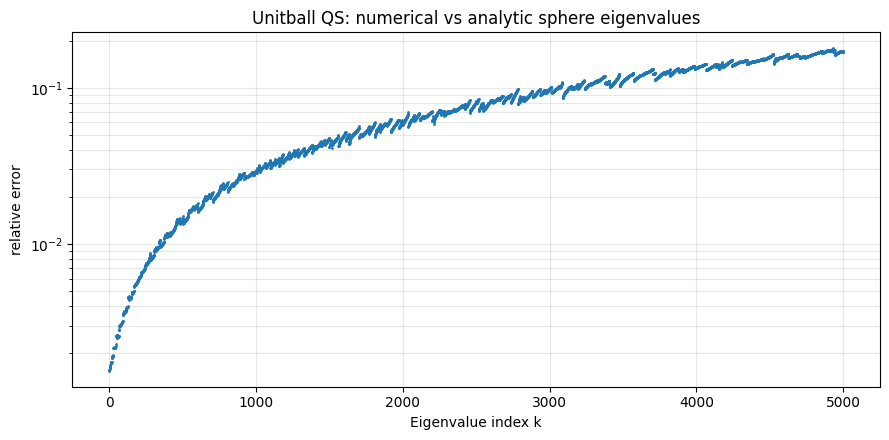

In [6]:
# ============================================================
# 5. Track A: Unitball benchmark
# ============================================================

unitball_outputs = {}

if CONFIG["run_unit_ball"]:
    truth_path = CONFIG["unit_ball_truth_path"]
    n_target = CONFIG["unit_ball"]["n_target"]
    truth = load_eigenvalues_txt(truth_path, n=n_target)

    if CONFIG["unit_ball_compute"]:
        print("Running fresh unitball solver benchmark ...")
        unitball_outputs = run_unit_ball_solver_benchmark(
            data_dir=CONFIG["data_dir"],
            truth_path=truth_path,
            n_target=n_target,
            mesh_size=CONFIG["unit_ball"]["mesh_size"],
            order=CONFIG["unit_ball"]["order"],
            solver=CONFIG["unit_ball"]["solver"],
            force_remesh=CONFIG["unit_ball"]["force_remesh"],
        )
        result = unitball_outputs["result"]
        df_compare = unitball_outputs["compare"]
        df_bands = unitball_outputs["bands"]

    else:
        eig_path = CONFIG["unit_ball_existing_eigs_path"]
        if not eig_path.exists():
            candidates = list(CONFIG["data_dir"].rglob("*unit_ball*P2*h008*N5000*slepc*eigs.txt"))
            if candidates:
                eig_path = candidates[0]
            else:
                raise FileNotFoundError(f"No existing unitball eigs found: {eig_path}")

        print("Loading existing numerical eigenvalues:", eig_path)
        eigs_num = load_eigenvalues_txt(eig_path, n=n_target)

        result = AlgorithmResult(
            algorithm=f"loaded:{eig_path.name}",
            eigs=eigs_num,
            runtime_sec=0.0,
            success=True,
            meta={"source": str(eig_path)},
        )

        df_compare = compare_to_truth(eigs_num, truth, n=n_target, label=result.algorithm)
        df_bands = error_bands(df_compare)

        unitball_outputs = {
            "result": result,
            "compare": df_compare,
            "bands": df_bands,
        }

    print(result)
    display(df_bands)

    # Save outputs
    df_compare.to_csv(OUT_DIR / "unitball_compare.csv", index=False)
    df_bands.to_csv(OUT_DIR / "unitball_error_bands.csv", index=False)
    save_eigenvalues_txt(OUT_DIR / "unitball_eigs_used.txt", result.eigs)

    fig = plot_unit_ball_error(df_compare, title="Unitball QS: numerical vs analytic sphere eigenvalues")
    fig.savefig(OUT_DIR / "unitball_relative_error.png", dpi=140, bbox_inches="tight")
    plt.show()
else:
    print("Track A disabled.")


# Track B — Reverse Geometry / Weyl-QS

Diese Spur prüft für den echten triaxialen Ellipsoid \(a=1,b=1.5,c=2.3\), wie gut Volumen und Oberfläche aus den ersten \(K\) Eigenwerten rekonstruiert werden.

Erwartete Input-Dateien:

```text
ssg_a1_b1.5_c2.3_eigenvalues.txt
ellipsoid_eigs_a1_b1.5_c2.3_arnoldi-1000.txt
```


,method,K,V_est,S_est,V_est_S_known,V_true,S_true,V_rel_err,S_rel_err,V_rel_err_S_known
0,SSG,50,12.961904,20.200509,15.124222,14.451326,31.355382,-0.103065,-0.355756,0.046563
1,SSG,100,13.707980,23.793162,14.908515,14.451326,31.355382,-0.051438,-0.241178,0.031636
2,SSG,200,13.985160,25.489168,14.742064,14.451326,31.355382,-0.032258,-0.187088,0.020118
3,SSG,300,14.042183,25.875640,14.666886,14.451326,31.355382,-0.028312,-0.174762,0.014916
4,SSG,500,14.053786,25.903392,14.584341,14.451326,31.355382,-0.027509,-0.173877,0.009204
5,SSG,700,13.586310,21.408300,14.454954,14.451326,31.355382,-0.059857,-0.317237,0.000251
6,SSG,1000,12.621678,11.049879,14.194874,14.451326,31.355382,-0.126608,-0.647592,-0.017746
7,SSG,1500,10.605336,-13.626593,13.616142,14.451326,31.355382,-0.266134,-1.434585,-0.057793
8,SSG,2000,8.428197,-43.742538,12.911366,14.451326,31.355382,-0.416787,-2.395057,-0.106562
9,SSG,3000,4.490243,-106.642501,11.339988,14.451326,31.355382,-0.689285,-4.401091,-0.215298


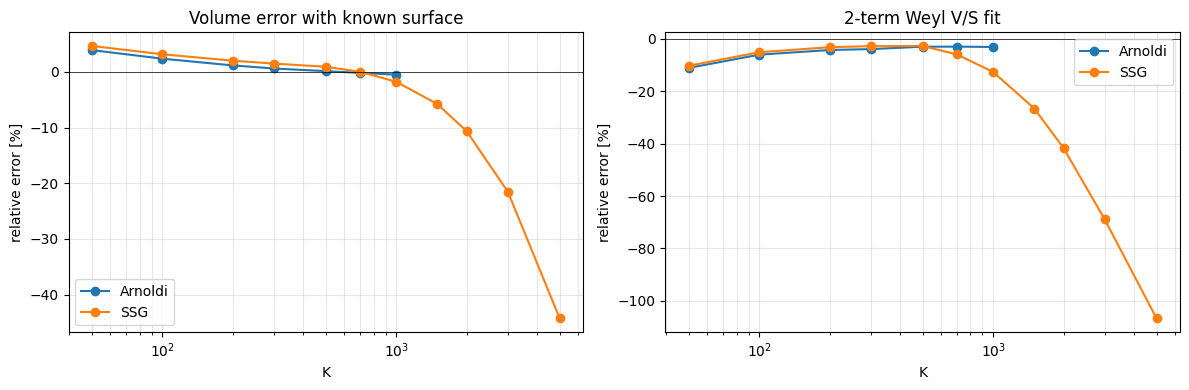

In [7]:
# ============================================================
# 6. Track B: Reverse Geometry / Weyl QS
# ============================================================

reverse_outputs = {}

if CONFIG["run_reverse_geometry"]:
    rg = CONFIG["reverse_geometry"]

    existing_files = {name: path for name, path in rg["eig_files"].items() if Path(path).exists()}
    missing_files = {name: path for name, path in rg["eig_files"].items() if not Path(path).exists()}

    if missing_files:
        print("Missing reverse-geometry files:")
        for name, path in missing_files.items():
            print(f"  {name}: {path}")

    if not existing_files:
        print("No reverse-geometry files found. Skipping Track B.")
    else:
        df_rg = run_reverse_geometry_benchmark(
            existing_files,
            a=rg["a"],
            b=rg["b"],
            c=rg["c"],
            k_values=rg["k_values"],
        )
        reverse_outputs["table"] = df_rg

        display(df_rg)

        df_rg.to_csv(OUT_DIR / "reverse_geometry_table.csv", index=False)

        fig = plot_reverse_geometry(df_rg)
        fig.savefig(OUT_DIR / "reverse_geometry.png", dpi=140, bbox_inches="tight")
        plt.show()
else:
    print("Track B disabled.")


# Track C — Block-Hankel / Multi-Probe FDM

Diese Spur führt den Multi-Probe-Block-Hankel-FDM-Lauf aus.

Konzept:

```text
K,M für Unitball
→ Chebyshev-Momente G_n
→ Fensterung
→ Block-Hankel-Pencil
→ Unique Match gegen unit_ball_N20000.txt
```

Der Lauf dauert mit \(K=7\), \(4000\) Momenten und \(8\) Fenstern typischerweise einige Minuten.


Block-FDM lambda_top = 561.368107 (reference index 800)


Transforming over 1000 vertices to C_CONTIGUOUS.
Transforming over 1000 elements to C_CONTIGUOUS.



FEM meta: {'mesh_path': PosixPath('/home/esul01/data/ellipsoid_a1_b1_c1_h0.08.msh'), 'assembly_sec': 1.1369497859850526}
K shape: (47321, 47321) M shape: (47321, 47321)
    400/4000
    800/4000
    1200/4000
    1600/4000
    2000/4000
    2400/4000
    2800/4000
    3200/4000
    3600/4000
    4000/4000

=== TRACK C — RAW BLOCK-HANKEL FDM ===
Block-FDM summary:


,method,n_raw,n_unique_matched,max_rel_err_threshold,ref_idx_min,ref_idx_max,median_rel_err,max_rel_err,q90_rel_err,coverage_1e_3,coverage_5e_3,coverage_1e_2,coverage_5e_2
0,block_hankel_fdm,142,139,0.05,0,778,0.006537,0.040691,0.01791,11,55,96,139


Block-FDM unique matches:


,i,lambda_num,lambda_ref,ref_idx,rel_err
0,0,9.868935,9.869604,0,0.000068
1,1,20.198734,20.190729,1,0.000396
2,2,20.335051,20.190729,2,0.007148
3,3,33.302089,33.217462,4,0.002548
4,5,48.500129,48.831194,10,0.006780
5,6,48.909684,48.831194,11,0.001607
6,7,49.297162,48.831194,12,0.009542
7,8,50.818176,48.831194,13,0.040691
8,9,58.709628,59.679516,17,0.016252
9,10,60.147165,59.679516,18,0.007836


saved: /home/esul01/data/outputs/orchestrated_benchmark_outputs/block_fdm_info.json


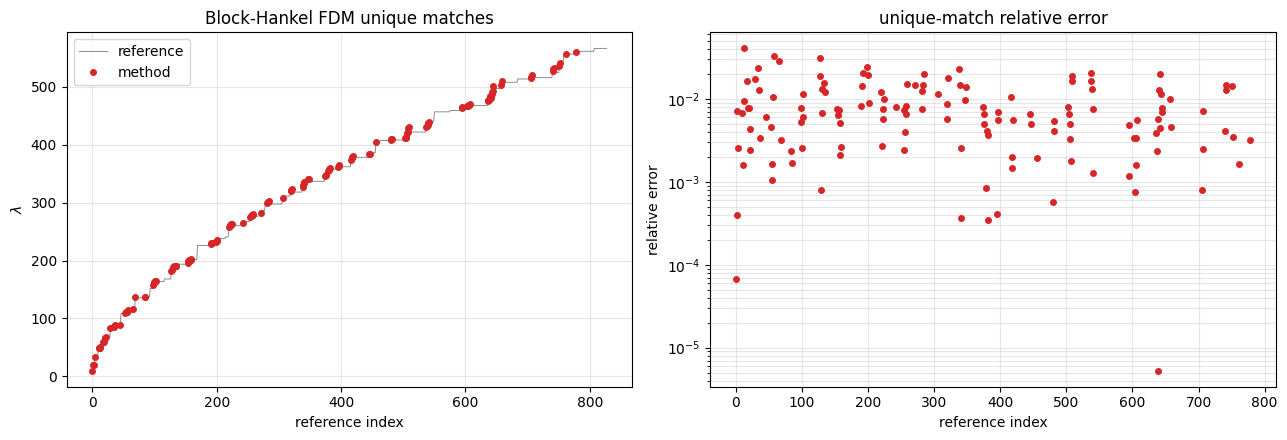

In [8]:
# ============================================================
# 7. Track C: Block-Hankel / Multi-Probe FDM
# ============================================================

block_fdm_outputs = {}

if CONFIG["run_block_fdm"]:
    bf = CONFIG["block_fdm"]
    truth_full = load_eigenvalues_txt(CONFIG["unit_ball_truth_path"], n=20_000)
    lambda_top = float(truth_full[bf["reference_index_top"]])

    print(f"Block-FDM lambda_top = {lambda_top:.6f} (reference index {bf['reference_index_top']})")

    mesh, K_ball, M_ball, fem_meta = load_or_create_problem(
        CONFIG["data_dir"],
        a=1.0,
        b=1.0,
        c=1.0,
        mesh_size=bf["mesh_size"],
        order=bf["order"],
        force_remesh=bf["force_remesh"],
    )
    print("FEM meta:", fem_meta)
    print("K shape:", K_ball.shape, "M shape:", M_ball.shape)

    lambdas_block, info_block = windowed_block_fdm(
        K_ball,
        M_ball,
        lambda_top=lambda_top,
        n_moments=bf["n_moments"],
        n_windows=bf["n_windows"],
        n_probes=bf["n_probes"],
        lambda_max=None,
        hankel_blocks=bf["hankel_blocks"],
        transition_frac=bf["transition_frac"],
        window_overlap=bf["window_overlap"],
        seed=bf["seed"],
        rank_tol=bf["rank_tol"],
        max_rank=bf["max_rank"],
        verbose=bf["verbose"],
    )

    summary_block, df_block_unique = summarize_unique_match(
        lambdas_block,
        truth_full,
        max_rel_err=0.05,
        label="block_hankel_fdm",
    )

    block_fdm_outputs = {
        "eigs": lambdas_block,
        "info": info_block,
        "summary": summary_block,
        "unique_match": df_block_unique,
        "fem_meta": fem_meta,
    }

    print("\n=== TRACK C — RAW BLOCK-HANKEL FDM ===")
    print("Block-FDM summary:")
    display(pd.DataFrame([summary_block]))

    print("Block-FDM unique matches:")
    display(df_block_unique.head(40))

    np.savetxt(OUT_DIR / "block_fdm_eigs.txt", lambdas_block, fmt="%.16e")
    df_block_unique.to_csv(OUT_DIR / "block_fdm_unique_matches.csv", index=False)
    save_json({k: v for k, v in info_block.items() if k != "windows"}, OUT_DIR / "block_fdm_info.json")
    pd.DataFrame([summary_block]).to_csv(OUT_DIR / "block_fdm_summary.csv", index=False)

    fig = plot_fdm_matches(df_block_unique, truth_full, title="Block-Hankel FDM unique matches")
    fig.savefig(OUT_DIR / "block_fdm_unique_matches.png", dpi=140, bbox_inches="tight")
    plt.show()
else:
    print("Track C disabled.")


# Track D — Stable-Pole-Filter

Diese Spur führt mehrere kleinere Block-Hankel-Läufe mit unterschiedlichen Seeds aus und behält nur wiederauftauchende Pole.

Das ist der robuste Gegenpol zum Rohfund:

```text
viele Kandidaten  ≠  stabile Pole
```


In [ ]:
# ============================================================
# 8. Track D: Stable-Pole Filter
# ============================================================

stable_outputs = {}

if CONFIG["run_block_fdm_stability"]:
    bf = CONFIG["block_fdm"]
    sf = CONFIG["block_fdm_stability"]
    truth_full = load_eigenvalues_txt(CONFIG["unit_ball_truth_path"], n=20_000)
    lambda_top = float(truth_full[bf["reference_index_top"]])

    # Reuse K_ball/M_ball if Track C already ran. Otherwise load/assemble.
    if "K_ball" not in globals() or "M_ball" not in globals():
        mesh, K_ball, M_ball, fem_meta = load_or_create_problem(
            CONFIG["data_dir"],
            a=1.0,
            b=1.0,
            c=1.0,
            mesh_size=bf["mesh_size"],
            order=bf["order"],
            force_remesh=bf["force_remesh"],
        )

    block_runs = []
    run_infos = []

    for seed in sf["seeds"]:
        print(f"Stable run seed={seed}")
        vals, inf = windowed_block_fdm(
            K_ball,
            M_ball,
            lambda_top=lambda_top,
            n_moments=sf["n_moments"],
            n_windows=sf["n_windows"],
            n_probes=sf["n_probes"],
            lambda_max=None,
            hankel_blocks=sf["hankel_blocks"],
            seed=seed,
            verbose=sf["verbose"],
        )
        print(f"  seed={seed}: n={len(vals)}, wall={inf['wall_seconds']:.1f}s")
        block_runs.append(vals)
        run_infos.append({"seed": seed, "n": len(vals), "wall_seconds": inf["wall_seconds"]})

    df_stable = stable_pole_filter(
        block_runs,
        min_count=sf["min_count"],
        rel_gap=sf["rel_gap"],
    )

    # Remove zero artifact for Dirichlet.
    df_stable = df_stable[df_stable["lambda_center"] > 1e-8].copy().reset_index(drop=True)

    stable_vals = df_stable["lambda_center"].to_numpy()

    summary_stable, df_stable_unique = summarize_unique_match(
        stable_vals,
        truth_full,
        max_rel_err=0.05,
        label="stable_block_hankel_fdm",
    )

    stable_outputs = {
        "stable_clusters": df_stable,
        "unique_match": df_stable_unique,
        "summary": summary_stable,
        "run_infos": run_infos,
    }

    print("\n=== TRACK D — STABLE-POLE FILTER ===")
    print("Stable clusters:")
    display(df_stable)

    print("Stable-pole summary:")
    display(pd.DataFrame([summary_stable]))

    print("Stable unique matches:")
    display(df_stable_unique.head(40))

    df_stable.to_csv(OUT_DIR / "stable_poles_clusters.csv", index=False)
    df_stable_unique.to_csv(OUT_DIR / "stable_poles_unique_matches.csv", index=False)
    pd.DataFrame([summary_stable]).to_csv(OUT_DIR / "stable_poles_summary.csv", index=False)
    pd.DataFrame(run_infos).to_csv(OUT_DIR / "stable_poles_run_infos.csv", index=False)

    fig = plot_fdm_matches(df_stable_unique, truth_full, title="Stable Block-Hankel FDM unique matches")
    fig.savefig(OUT_DIR / "stable_poles_unique_matches.png", dpi=140, bbox_inches="tight")
    plt.show()
else:
    print("Track D disabled.")


Stable run seed=42
  seed=42: n=108, wall=751.3s
Stable run seed=137
  seed=137: n=111, wall=3477.5s
Stable run seed=271


# Track E — SSG triaxial

Diese Spur integriert den Stretched-Spectral-Galerkin-Solver in denselben `AlgorithmResult`-Vertrag wie SLEPc, ARPACK, Block-Hankel-FDM und DMC.


In [ ]:
# ============================================================
# 10. Track E: SSG triaxial
# ============================================================

ssg_outputs = {}

if CONFIG.get("run_ssg_triaxial", False):
    print("\n=== TRACK E — SSG TRIAXIAL ===")

    cfg = CONFIG["ssg_triaxial"]
    a, b, c = cfg["a"], cfg["b"], cfg["c"]

    if cfg.get("run_sanity", False):
        print("\n--- SSG sanity: unit ball ---")
        sanity = cfg["sanity"]

        # Use n_eigs=None for full dense diagonalization; the sanity basis
        # is small (a few hundred dofs) so this is faster and more robust
        # than a sparse partial solver.
        res_sanity = solve_ssg(
            a=1.0, b=1.0, c=1.0,
            l_max=sanity["l_max"],
            n_max=sanity["n_max"],
            n_radial=sanity["n_radial"],
            n_theta=sanity["n_theta"],
            n_phi=sanity["n_phi"],
            n_eigs=None,
            block_size=cfg.get("block_size"),
            verbose=True,
        )

        # Compare the lower part of the spectrum: the basis (l_max,n_max)
        # only resolves a limited range; check the first 50 reliably-converged
        # eigenvalues to detect any regression in the SSG kernel.
        n_sanity_check = min(50, len(res_sanity.eigs))
        truth = load_eigenvalues_txt(CONFIG["unit_ball_truth_path"], n=n_sanity_check)
        df_sanity = compare_to_truth(res_sanity.eigs, truth, n=n_sanity_check, label="ssg_sanity_unitball")
        max_rel = float(df_sanity["abs_rel_err"].max()) if len(df_sanity) else np.nan

        print(res_sanity)
        print(f"max sanity relative error: {max_rel:.2e}")
        sanity_target = sanity.get("max_rel_err_target", 1e-12)
        sanity_passed = bool(np.isfinite(max_rel) and max_rel < sanity_target)
        if sanity_passed:
            print(f"  SSG sanity PASSED (target < {sanity_target:.0e})")
        else:
            print(f"  WARNING: SSG sanity FAILED (got {max_rel:.2e}, target < {sanity_target:.0e})")

        ssg_outputs["sanity_passed"] = sanity_passed
        ssg_outputs["sanity_result"] = res_sanity
        ssg_outputs["sanity_compare"] = df_sanity
        df_sanity.to_csv(OUT_DIR / "ssg_sanity_unitball_compare.csv", index=False)

    ref_path = cfg["reference_path"]
    ref_eigs = load_eigenvalues_txt(ref_path, n=cfg["n_compare"]) if Path(ref_path).exists() else None

    convergence_rows = []
    results = []

    for l_max, n_max, n_radial, n_theta, n_phi in cfg["configs"]:
        print("\n" + "-" * 80)
        print(f"SSG config: l_max={l_max}, n_max={n_max}, quad=({n_radial},{n_theta},{n_phi})")
        print("-" * 80)

        res = solve_ssg(
            a=a, b=b, c=c,
            l_max=l_max,
            n_max=n_max,
            n_radial=n_radial,
            n_theta=n_theta,
            n_phi=n_phi,
            n_eigs=None,
            block_size=cfg.get("block_size"),
            verbose=True,
        )
        results.append(res)

        row = {
            "l_max": l_max,
            "n_max": n_max,
            "n_radial": n_radial,
            "n_theta": n_theta,
            "n_phi": n_phi,
            "success": res.success,
            "runtime_sec": res.runtime_sec,
            "n_eigs": len(res.eigs),
            "n_basis": res.meta.get("n_basis", np.nan),
            "lambda_1": float(res.eigs[0]) if len(res.eigs) else np.nan,
            "message": res.message,
        }

        if ref_eigs is not None and len(res.eigs):
            n_cmp = min(cfg["n_compare"], len(res.eigs), len(ref_eigs))
            rel_signed = (res.eigs[:n_cmp] - ref_eigs[:n_cmp]) / ref_eigs[:n_cmp]
            row["median_signed_rel_err_vs_arnoldi"] = float(np.median(rel_signed))
            row["median_abs_rel_err_vs_arnoldi"] = float(np.median(np.abs(rel_signed)))
            row["fraction_below_arnoldi"] = float((rel_signed < 0).mean())
            row["n_compare"] = int(n_cmp)

        convergence_rows.append(row)
        print("result:", res)
        print("lambda_1:", row["lambda_1"])
        print("runtime_sec:", row["runtime_sec"])
        print("n_basis:", row["n_basis"])

    df_conv = pd.DataFrame(convergence_rows)
    display(df_conv)
    df_conv.to_csv(OUT_DIR / "ssg_triaxial_convergence.csv", index=False)

    successful = [r for r in results if r.success and len(r.eigs)]
    if successful:
        finest = successful[-1]
        save_eigenvalues_txt(cfg["save_eigs_to"], finest.eigs)
        save_eigenvalues_txt(OUT_DIR / "ssg_triaxial_finest_eigs.txt", finest.eigs)
        ssg_outputs["finest_result"] = finest
        ssg_outputs["eigs"] = finest.eigs

    ssg_outputs["results"] = results
    ssg_outputs["convergence"] = df_conv

    if len(df_conv):
        last = df_conv.iloc[-1]
        ssg_outputs["median_signed_rel_err"] = float(last.get("median_signed_rel_err_vs_arnoldi", np.nan))
        ssg_outputs["fraction_below_arnoldi"] = float(last.get("fraction_below_arnoldi", np.nan))

else:
    print("Track E disabled.")


# Track F — DMC ground state validation

Diese Spur nutzt bridge-corrected Diffusion Monte Carlo als unabhängigen Ground-State-Check. DMC liefert nur \(\lambda_1\), kein volles Spektrum.


In [ ]:
# ============================================================
# 11. Track F: DMC ground state validation
# ============================================================

dmc_outputs = {}

if CONFIG.get("run_dmc", False):
    print("\n=== TRACK F — DMC GROUND STATE VALIDATION ===")

    cfg = CONFIG["dmc"]

    if cfg.get("run_sanity", False):
        print("\n--- DMC sanity: unit ball ---")
        s = cfg["sanity"]

        res_dmc_sanity = solve_dmc_lambda1(
            a=s["a"], b=s["b"], c=s["c"],
            n_walkers_per_run=s["n_walkers_per_run"],
            n_runs_per_dt=s["n_runs_per_dt"],
            dts=s["dts"],
            n_cores=s["n_cores"],
            verbose=True,
        )

        pi2 = float(np.pi ** 2)
        rel_err_pi2 = abs(float(res_dmc_sanity.eigs[0]) - pi2) / pi2 if len(res_dmc_sanity.eigs) else np.nan

        print(res_dmc_sanity)
        print(f"pi^2 reference: {pi2:.8f}")
        print(f"DMC sanity rel.err: {rel_err_pi2:.6e}")

        dmc_outputs["sanity"] = res_dmc_sanity
        dmc_outputs["sanity_rel_err_pi2"] = rel_err_pi2

    if cfg.get("run_triaxial", False):
        print("\n--- DMC triaxial ---")
        tcfg = cfg["triaxial"]

        res_dmc_tri = solve_dmc_lambda1(
            a=tcfg["a"], b=tcfg["b"], c=tcfg["c"],
            n_walkers_per_run=tcfg["n_walkers_per_run"],
            n_runs_per_dt=tcfg["n_runs_per_dt"],
            dts=tcfg["dts"],
            n_cores=tcfg["n_cores"],
            verbose=True,
        )

        print(res_dmc_tri)
        comparisons = []

        if Path(cfg["ssg_eigs_path"]).exists():
            ssg_eigs = load_eigenvalues_txt(cfg["ssg_eigs_path"], n=1)
            if len(ssg_eigs) and len(res_dmc_tri.eigs):
                comparisons.append({
                    "reference": "SSG",
                    "lambda_ref": float(ssg_eigs[0]),
                    "lambda_dmc": float(res_dmc_tri.eigs[0]),
                    "signed_rel_err": float((res_dmc_tri.eigs[0] - ssg_eigs[0]) / ssg_eigs[0]),
                })

        if Path(cfg["arnoldi_eigs_path"]).exists():
            arnoldi_eigs = load_eigenvalues_txt(cfg["arnoldi_eigs_path"], n=1)
            if len(arnoldi_eigs) and len(res_dmc_tri.eigs):
                comparisons.append({
                    "reference": "Arnoldi",
                    "lambda_ref": float(arnoldi_eigs[0]),
                    "lambda_dmc": float(res_dmc_tri.eigs[0]),
                    "signed_rel_err": float((res_dmc_tri.eigs[0] - arnoldi_eigs[0]) / arnoldi_eigs[0]),
                })

        df_dmc_compare = pd.DataFrame(comparisons)
        display(df_dmc_compare)
        df_dmc_compare.to_csv(OUT_DIR / "dmc_triaxial_compare_lambda1.csv", index=False)

        dmc_outputs["triaxial"] = res_dmc_tri
        dmc_outputs["triaxial_compare"] = df_dmc_compare

    dmc_meta = {}
    for key, res in dmc_outputs.items():
        if isinstance(res, AlgorithmResult):
            dmc_meta[key] = {
                "algorithm": res.algorithm,
                "success": res.success,
                "runtime_sec": res.runtime_sec,
                "eigs": res.eigs.tolist(),
                "message": res.message,
                "meta": res.meta,
            }

    save_json(dmc_meta, OUT_DIR / "dmc_outputs_meta.json")

else:
    print("Track F disabled.")


# One-Page Summary

Diese Zelle sammelt die wichtigsten Kennzahlen in eine kleine Summary-Tabelle.


In [ ]:
# ============================================================
# 9. Summary table
# ============================================================

summary_rows = []

if unitball_outputs:
    df_bands = unitball_outputs["bands"]
    result = unitball_outputs["result"]

    row = {
        "track": "Unitball QS",
        "method": result.algorithm,
        "n": result.n_found,
        "runtime_sec": result.runtime_sec,
        "metric_1": "median rel.err all compared",
        "value_1": float(unitball_outputs["compare"]["abs_rel_err"].median()),
        "metric_2": "max rel.err all compared",
        "value_2": float(unitball_outputs["compare"]["abs_rel_err"].max()),
    }
    summary_rows.append(row)

if reverse_outputs:
    df_rg = reverse_outputs["table"]
    for method, part in df_rg.groupby("method"):
        # Pick best by known-surface volume error.
        part2 = part.dropna(subset=["V_rel_err_S_known"]).copy()
        if len(part2):
            best = part2.iloc[np.argmin(np.abs(part2["V_rel_err_S_known"].to_numpy()))]
            summary_rows.append({
                "track": "Reverse Geometry",
                "method": method,
                "n": int(best["K"]),
                "runtime_sec": np.nan,
                "metric_1": "best |V err| with S known",
                "value_1": float(abs(best["V_rel_err_S_known"])),
                "metric_2": "signed V err with S known",
                "value_2": float(best["V_rel_err_S_known"]),
            })

if block_fdm_outputs:
    s = block_fdm_outputs["summary"]
    summary_rows.append({
        "track": "Block-Hankel FDM",
        "method": "raw unique match",
        "n": s["n_unique_matched"],
        "runtime_sec": block_fdm_outputs["info"]["wall_seconds"],
        "metric_1": "median rel.err",
        "value_1": s["median_rel_err"],
        "metric_2": "q90 rel.err",
        "value_2": s["q90_rel_err"],
    })

if stable_outputs:
    s = stable_outputs["summary"]
    summary_rows.append({
        "track": "Stable Block-Hankel FDM",
        "method": "stable poles",
        "n": s["n_unique_matched"],
        "runtime_sec": sum(r["wall_seconds"] for r in stable_outputs["run_infos"]),
        "metric_1": "median rel.err",
        "value_1": s["median_rel_err"],
        "metric_2": "q90 rel.err",
        "value_2": s["q90_rel_err"],
    })


if "ssg_outputs" in globals() and ssg_outputs:
    conv = ssg_outputs.get("convergence", pd.DataFrame())
    finest = conv.iloc[-1] if len(conv) else None
    if finest is not None:
        summary_rows.append({
            "track": "SSG triaxial",
            "method": f"ssg_l{int(finest['l_max'])}_n{int(finest['n_max'])}",
            "n": int(finest["n_basis"]) if not pd.isna(finest["n_basis"]) else np.nan,
            "runtime_sec": float(finest["runtime_sec"]),
            "metric_1": "median signed rel.err vs Arnoldi",
            "value_1": ssg_outputs.get("median_signed_rel_err", np.nan),
            "metric_2": "fraction below Arnoldi",
            "value_2": ssg_outputs.get("fraction_below_arnoldi", np.nan),
        })

if "dmc_outputs" in globals() and dmc_outputs.get("triaxial"):
    r = dmc_outputs["triaxial"]
    summary_rows.append({
        "track": "DMC triaxial",
        "method": r.algorithm,
        "n": 1,
        "runtime_sec": r.runtime_sec,
        "metric_1": "lambda_1",
        "value_1": r.meta["lambda_1"],
        "metric_2": "lambda_1 SEM",
        "value_2": r.meta["lambda_1_err"],
    })

df_summary = pd.DataFrame(summary_rows)
display(df_summary)

df_summary.to_csv(OUT_DIR / "summary_table.csv", index=False)
print("All outputs saved to:", OUT_DIR)


# Recommended Configurations

## Fast validation

```python
CONFIG["run_unit_ball"] = True
CONFIG["unit_ball_compute"] = False
CONFIG["run_reverse_geometry"] = True
CONFIG["run_block_fdm"] = False
CONFIG["run_block_fdm_stability"] = False
```

## Full daily run

```python
CONFIG["run_unit_ball"] = True
CONFIG["unit_ball_compute"] = False
CONFIG["run_reverse_geometry"] = True
CONFIG["run_block_fdm"] = True
CONFIG["run_block_fdm_stability"] = True
```

## Fresh SLEPc production run

```python
CONFIG["unit_ball_compute"] = True
CONFIG["unit_ball"]["n_target"] = 5000
CONFIG["unit_ball"]["mesh_size"] = 0.08
CONFIG["unit_ball"]["solver"] = "slepc"
```
